# Screen Time, Sleep, and Productivity Analysis

## Introduction

This project aims to analyze the relationship between screen time, sleep hours, and productivity. Instead of using a subjective productivity score, task count was used as a more objective measure of daily performance. The data was collected manually over several days.

## Data Collection

Screen time data was obtained from the iPhone screen time feature. Sleep hours and task counts were recorded manually on a daily basis. The dataset includes daily observations from April 6 to April 13.The data was collected manually, which may introduce some subjectivity.

## Analysis

Three main visualizations were created. The first graph shows how task count changes over time. The second graph explores the relationship between sleep hours and task count. The third graph examines how screen time relates to task completion.

A correlation matrix was also calculated to better understand the relationships between variables.

## Results

The results show that there is a positive relationship between sleep hours and task count. As sleep duration increases, the number of completed tasks generally increases.

On the other hand, screen time does not show a strong positive relationship with task count. In some cases, higher screen time is associated with lower task completion.

Overall, sleep appears to have a stronger impact on productivity compared to screen time.

## Conclusion

This project suggests that improving sleep habits may lead to better productivity. While reducing screen time might help, it does not appear to be as influential as sleep. More data would be needed to confirm these findings.However, the dataset is limited to a short time period, which may affect the reliability of the results.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# DATASET

In [11]:
data = {
    "date": [
        "2026-04-06", "2026-04-07", "2026-04-08", "2026-04-09",
        "2026-04-10", "2026-04-11", "2026-04-12", "2026-04-13",
        "2026-04-14", "2026-04-15", "2026-04-16", "2026-04-17",
        "2026-04-18", "2026-04-19", "2026-04-20", "2026-04-21",
        "2026-04-22", "2026-04-23", "2026-04-24", "2026-04-25",
        "2026-04-26", "2026-04-27", "2026-04-28", "2026-04-29",
        "2026-04-30", "2026-05-01", "2026-05-02", "2026-05-03",
        "2026-05-04", "2026-05-05", "2026-05-06"
    ],
    "screen_time": [
        7.6, 7.2, 5.4, 9.6, 6.3, 6.6, 8.1, 7.6,
        7.9, 6.4, 5.8, 8.9, 9.3, 7.7, 6.1, 7.4,
        5.9, 6.8, 8.2, 9.7, 8.5, 6.6, 5.5, 7.1,
        6.0, 8.4, 9.1, 7.8, 6.3, 5.7, 7.0
    ],
    "sleep_hours": [
        5, 5, 9, 8, 9, 6, 8, 9,
        6.5, 7, 7.5, 5.5, 6, 8, 7,
        6, 8.5, 7, 5, 6.5, 8, 6,
        7.5, 8, 6.5, 5.5, 7, 8.5, 6,
        7.5, 7
    ],
    "task_count": [
        3, 3, 5, 4, 5, 3, 4, 4,
        3, 4, 4, 3, 2, 4, 5,
        3, 5, 4, 2, 3, 4, 4,
        5, 4, 4, 3, 3, 5, 4,
        5, 4
    ]
}

In [12]:
df = pd.DataFrame(data)


#  GRAPH 1: Task Count Over Time

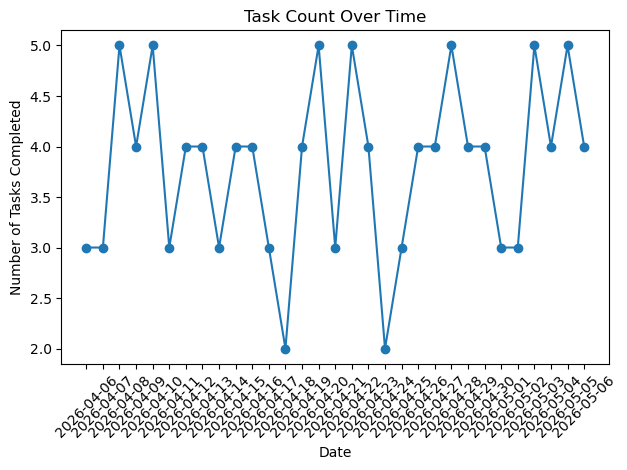

In [13]:
plt.figure()
plt.plot(df["date"], df["task_count"], marker="o")
plt.title("Task Count Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Tasks Completed")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#  GRAPH 2: Sleep vs Task Count

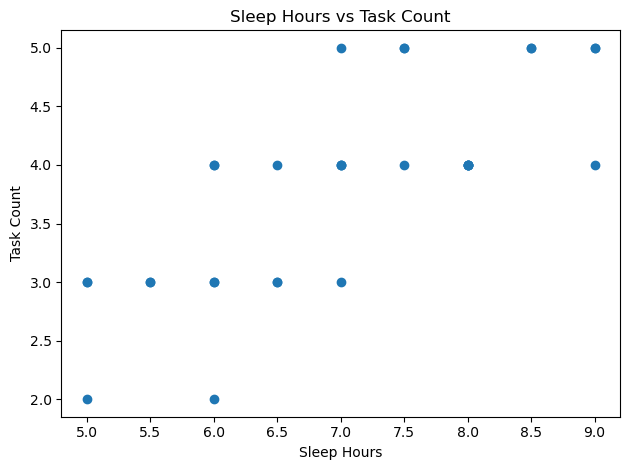

In [14]:
plt.figure()
plt.scatter(df["sleep_hours"], df["task_count"])
plt.title("Sleep Hours vs Task Count")
plt.xlabel("Sleep Hours")
plt.ylabel("Task Count")
plt.tight_layout()
plt.show()

#  GRAPH 3: Screen Time vs Task Count

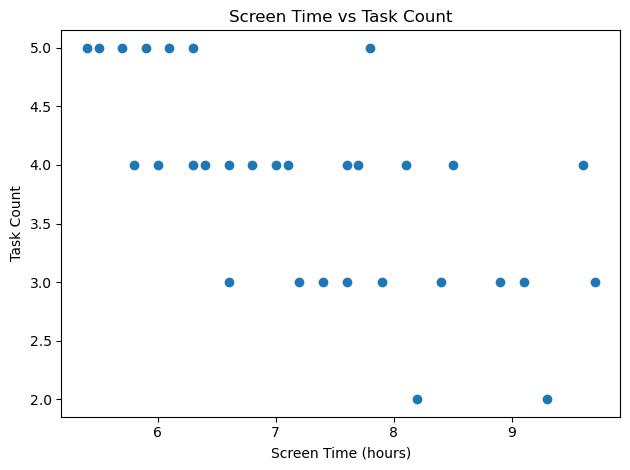

In [15]:
plt.figure()
plt.scatter(df["screen_time"], df["task_count"])
plt.title("Screen Time vs Task Count")
plt.xlabel("Screen Time (hours)")
plt.ylabel("Task Count")
plt.tight_layout()
plt.show()

#  CORRELATION MATRIX

In [16]:
print("\nCorrelation Matrix:")
print(df[["screen_time", "sleep_hours", "task_count"]].corr())


Correlation Matrix:
             screen_time  sleep_hours  task_count
screen_time     1.000000    -0.247512   -0.650057
sleep_hours    -0.247512     1.000000    0.752827
task_count     -0.650057     0.752827    1.000000


## Machine Learning Analysis

For the machine learning part, a linear regression model was used to predict daily task count based on screen time and sleep hours. Since the dataset is relatively small, the model is used as a simple exploratory method rather than a highly reliable prediction tool.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df[["screen_time", "sleep_hours"]]
y = df["task_count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Coefficients: [-0.34604692  0.41517749]
Intercept: 3.4297410681796867
MAE: 0.3010942650323516
R² Score: 0.7195432786583857


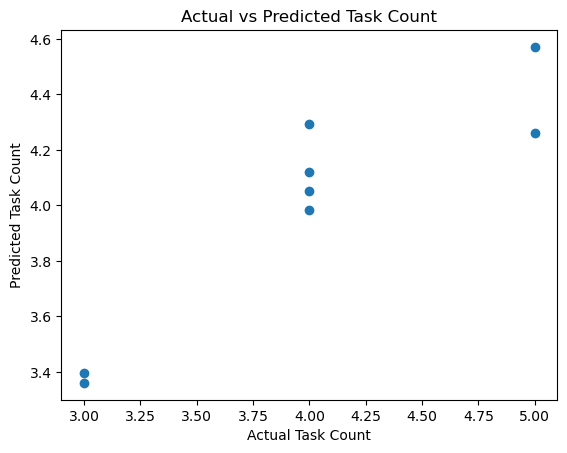

In [18]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Task Count")
plt.ylabel("Predicted Task Count")
plt.title("Actual vs Predicted Task Count")
plt.show()

## ML Result

The linear regression model gives a general idea of how screen time and sleep hours are related to task completion. The results suggest that sleep hours are more positively related to productivity, while screen time does not appear to improve task count. However, because the dataset is small and manually collected, the model should be interpreted carefully.The scatter plot shows that the model captures the general trend, but predictions are not perfectly aligned with actual values due to the small dataset.